# December 3, 2025
### This is a notebook to perform MCA on 251030_JANP-132_LT

In [7]:
from sklearn.decomposition import PCA
import prince
import mca

import sys, common, pickle, collections, math, numpy, scipy.stats
from pyx import *
from icecream import ic
import pandas as pd
from Bio import SeqIO
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

## Functions

In [23]:
def parsePickleFile(pickleFile, barcodeDict=None):
    """
    dataDict is of format:
    {readID:{edit_string,barcode,query_string,ref_string,aligned_pairs:...}}
    Will sort reads according to barcode, and output a tally of the number
    of reads per barcode. Will also compute the total size (in nts) of each
    barcode, to get a sense of coverage.
    
    Will output a dictionary of format:
    {bc:{readID:{position:edit}}}
    """
    ##start by unpickling the input file
    with open(pickleFile,'rb') as f:
        dataDict=pickle.load(f)
    ##
    aa=collections.defaultdict(lambda:collections.defaultdict(int))
    for readID,subDict in dataDict.items():
        bc=subDict['barcode']
        if barcodeDict is not None:
            if bc not in barcodeDict:
                continue
        queryLength=len(subDict['read_sequence'])
        aa[bc]['ct']+=1
        aa[bc]['length']+=queryLength
    ##
    for k,v in aa.items():
        print('Barcode %s had %s sequences totaling %s kilo nts.'%(\
            k,v['ct'],v['length']/1000))
    ##
    bb=collections.defaultdict(lambda:collections.defaultdict(dict))
    ##
    for readID,subDict in dataDict.items():
        barCode=subDict['barcode']
        #print(barCode,readID)
        editString=subDict['edit_string']
        #print(editString,len(editString))
        readSeq=subDict['read_sequence_aligned']
        #print(readSeq,len(readSeq))
        refSeq=subDict['ref_sequence_aligned']
        #print(refSeq,len(refSeq))
        alignedPairs=subDict['aligned_pairs']
        #print(alignedPairs,len(alignedPairs))
        #sys.exit()
        if barcodeDict is not None:
            if barCode not in barcodeDict:
                continue
        for ii in range(len(alignedPairs)-1):
            entry=alignedPairs[ii]
            idx=entry[0]
            absIdx=entry[1]
            if idx!=None and absIdx!=None:
                seq=refSeq[ii]
                edit=editString[ii]
                if seq=='A' and edit!='2' and absIdx<=704:
                    ##695 is where the RT primer binds--anything past this
                    ##is artifact.
                    bb[barCode][readID][absIdx]=int(edit)
    ##
    return bb

def parseBarcodeFile(barcodeFile):
    '''
    Given a barcode txt file, will return a dict of
    {barcode:library_name}
    '''
    bcDict={}
    with open(barcodeFile,'r') as f:
        for line in f:
            line=line.rstrip()
            print(line)
            if line=='':
                continue
            parts=line.split(',')
            bc=parts[0]
            libName=parts[1]
            bcDict[bc]=libName
    ##
    return bcDict

def formatForMCA(dataDict,numReads,minEditFreq,maxEditFreq):
    """
    dataDict={bc:{readID:{position:1/0}}}
    numReads is an integer.
    minEditFreq is a frequency (e.g., 0.7)
    maxEditFreq is a frequency (e.g., 1.0)
    Will sort each bc's readIDs by longest -> shortest, and then select the
    numReads longest reads with at least minEditFreq of 1's
    Will then convert to a list-of-lists like:
    [[0,1,1,0,...,1],
     [1,1,0,1,...,1],
     ...
     [1,0,0,0,...,0]]
     where each row represents a different readID. Will also return a list
     of bcs, which are the row labels.
    """
    aa=[]
    ##This part just gets the numReads reads from each bc
    for bc,readDict in dataDict.items():
        temp=[]
        for readID,positDict in readDict.items():
            if sum(positDict.values())/len(positDict)>=minEditFreq and \
               sum(positDict.values())/len(positDict)<=maxEditFreq:
                temp.append(len(positDict))
        ##
        temp.sort()
        temp.reverse()
        ##
        temp2=[]
        for readID,positDict in readDict.items():
            if len(positDict) in temp[:numReads]:
                if sum(positDict.values())/len(positDict)>=minEditFreq:
                    temp2.append((bc,positDict))
            if len(temp2)==numReads:
                break
        ##
        aa+=temp2
    ##
    ##now get all the positions
    positions=[]
    for entry in aa:
        for k in entry[1]:
            positions.append(k)
    ##now get unique positions, and then sort them
    positions=list(set(positions))
    positions.sort()
    ##now prepare outputs
    matrixOfEdits=[]
    listOfBCs=[]
    for entry in aa:
        ##record the bc
        listOfBCs.append(entry[0])
        ##now convert the dict to a vector/list
        temp=[]
        for k in positions:
            # cluster on lysine window [220, 380]
            if k in entry[1]:
                if k >= 220 and k <= 380:
                    v=entry[1][k]
                else:
                    v=numpy.nan##in case no value
            else:
                v=numpy.nan##in case no value
            temp.append(v)
        ##
        matrixOfEdits.append(temp)
    ##
    return matrixOfEdits,listOfBCs

def doMCAandPlot(matrixOfEdits,listOfBCs,outPrefix):
    """
    matrixOfEdits is a list of lists, where each list is a list of 1/0/nan
    indicated edit status. listOfBCs are the labels associated with that.
    Will run MCA and plot the first two components.
    """
    ##convert to DF
    X = pd.DataFrame(matrixOfEdits,\
        columns=['A%s'%(ii) for ii in range(len(matrixOfEdits[0]))])
    ##initialize mca
    mca = prince.MCA(n_components=5, n_iter=5, \
        copy=True, check_input=True, engine='sklearn', \
        random_state=42, correction="greenacre")
    ##
    mca_fit = mca.fit(X)
    X_mca = mca_fit.transform(X)
    ##create labels, but don't actually attached them to the DF
    labels = pd.Series(listOfBCs, name='label')
    ##add the labels
    X_mca['label'] = labels.values
    ##print some results
    print(mca.eigenvalues_summary)
    print(mca.column_coordinates(X))
    ##
    for ii in range(4):
        ##plot the data
        fig, ax = plt.subplots(figsize=(6, 6))
        for label in X_mca['label'].unique():
            subset = X_mca[X_mca['label'] == label]
            ax.scatter(subset[ii], subset[ii+1], label=label)
        ##set axis labels
        ax.set_title('MCA of Binary Vectors')
        ax.set_xlabel('MCA Dimension %s'%(ii+1))##+1 b/c python 0-based
        ax.set_ylabel('MCA Dimension %s'%(ii+2))
        ax.legend()
        ##save output
        plt.savefig('%s.%s.%s.png'%(outPrefix,ii,ii+1))
        plt.show()
        plt.close()
    # plot heatmap of column contributions
    contributions = mca.column_contributions_
    print(contributions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(contributions, cmap='viridis')
    plt.title('Column Contributions to MCA Dimensions')
    plt.xlabel('MCA Dimensions')
    plt.ylabel('Positions')
    plt.savefig(f"{outPrefix}_mca_column_contributions_heatmap.png", dpi=300)
    plt.close()

## Load Data

In [18]:
pickle_path = '/data16/liam/working/data/alignments/251030_JANP-132_LT/pickles/five_percent_full.sorted_nanoluc.pickle' # weird stuff going on with pathlib and pickle files!!
barcodeFile = Path('/data16/liam/working/data/alignments/251030_JANP-132_LT/barcodeFile.txt')
barcodeDict = parseBarcodeFile(barcodeFile)
read_dict = parsePickleFile(pickle_path, barcodeDict=barcodeDict)
outPrefix = Path('/data16/liam/working/data/alignments/251030_JANP-132_LT/mca_figures/')

bc1,-Lys
bc2,All
Barcode bc1 had 8051 sequences totaling 5881.605 kilo nts.
Barcode bc2 had 13977 sequences totaling 10231.988 kilo nts.


In [28]:
matrixOfEdits,listOfBCs = formatForMCA(read_dict,5000,0.35,0.4)

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.005        28.74%                     28.74%
1              0.003        18.39%                     47.13%
2              0.002        10.98%                     58.11%
3              0.001         8.29%                     66.40%
4              0.001         7.08%                     73.49%
                  0         1         2         3         4
A60__0.0  -0.047528 -0.009988 -0.001225 -0.055636 -0.013237
A60__1.0   0.390684  0.080005  0.016701  0.444948  0.086006
A61__0.0  -0.059261 -0.019113  0.002851 -0.056652 -0.017472
A61__1.0   0.645004  0.186126 -0.023017  0.592601  0.168186
A62__0.0  -0.079878 -0.015904  0.014331 -0.061308 -0.025702
...             ...       ...       ...       ...       ...
A117__1.0  0.037580  0.276428 -0.124941 -0.096582 -0.240251
A118__0.0 -0.058991 -0.393500  0.178203  0.145941  0.303995
A118__1.0  0.045583  0.288

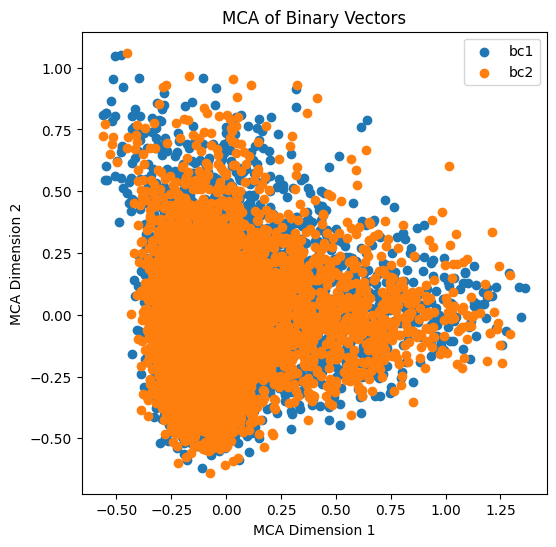

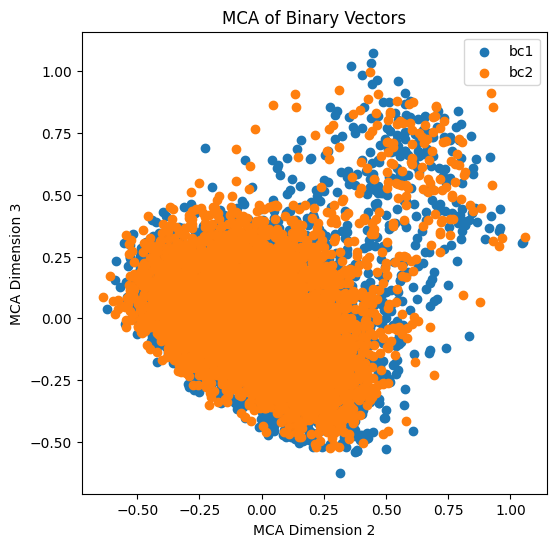

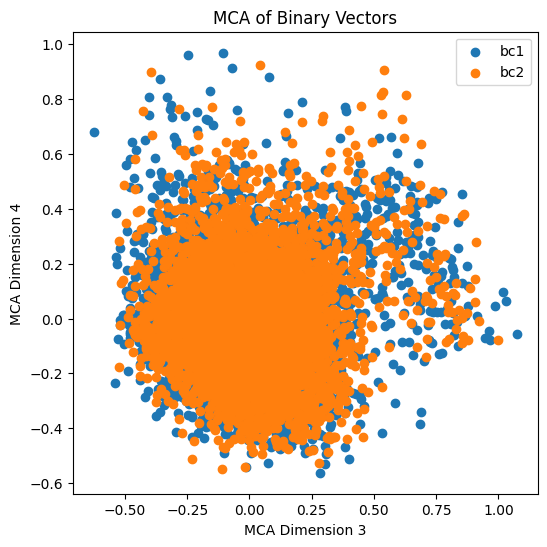

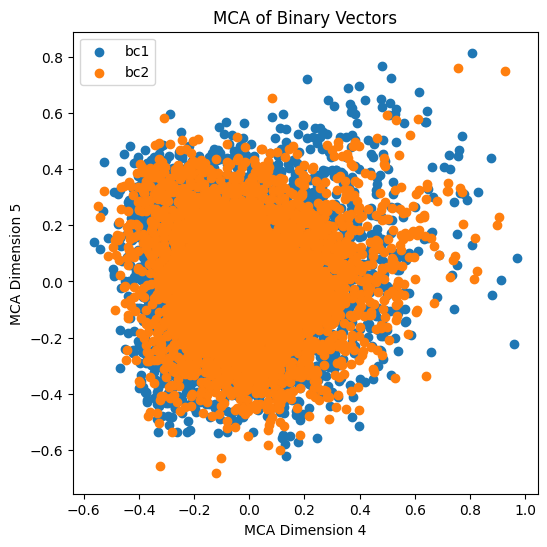

                  0         1         2         3         4
A60__0.0   0.007340  0.000506  0.000013  0.034854  0.002309
A60__1.0   0.062727  0.004110  0.000300  0.281946  0.012331
A61__0.0   0.011790  0.001916  0.000071  0.037338  0.004157
A61__1.0   0.130727  0.017007  0.000436  0.382391  0.036053
A62__0.0   0.022497  0.001393  0.001895  0.045924  0.009448
...             ...       ...       ...       ...       ...
A117__1.0  0.002967  0.250815  0.085852  0.067914  0.491902
A118__0.0  0.005415  0.376410  0.129346  0.114843  0.583262
A118__1.0  0.004401  0.275689  0.094037  0.084695  0.425865
A119__0.0  0.004762  0.450012  0.159937  0.074151  0.812095
A119__1.0  0.001715  0.156367  0.054564  0.026434  0.279291

[120 rows x 5 columns]


In [29]:
doMCAandPlot(matrixOfEdits,listOfBCs,outPrefix / '251203_MCA')